In [10]:
import xarray as xr, matplotlib, matplotlib.pyplot as plt, numpy as np, xvec, geopandas as gpd, datetime, regionmask, os, glob, re, pandas as pd
from IPython.display import clear_output
from shapely import Polygon

xn,xx,yn,yx = [-10.5,20,40,60] # Theo study region

fpath = "/rds/general/user/cb2714/home/00_WWA_project_folder/ephemeral/euro_heat/"

# Study region shapefile

In [ ]:
gdf = gpd.GeoDataFrame(geometry = [Polygon(zip([xn,xn,xx,xx,xn], [yn,yx,yx,yn,yn]))], crs="EPSG:4326")
gdf.to_file("sf_studyregion")

# Gridded obs datasets

## Download

### GMST

In [2]:
! wget https://climexp.knmi.nl/data/igiss_al_gl_a_4yrlo.dat -O data/gmst.dat

--2026-06-19 16:11:02--  https://climexp.knmi.nl/data/igiss_al_gl_a_4yrlo.dat
Resolving climexp.knmi.nl (climexp.knmi.nl)... 2a0c:5bc0:4c:ff::9126:ce95, 145.38.206.149
connected. to climexp.knmi.nl (climexp.knmi.nl)|2a0c:5bc0:4c:ff::9126:ce95|:443... 
HTTP request sent, awaiting response... 200 OK
Length: 4768 (4.7K)
Saving to: ‘data/gmst.dat’

data/gmst.dat       100%[===================>]   4.66K  --.-KB/s    in 0s      

2026-06-19 16:11:02 (47.9 MB/s) - ‘data/gmst.dat’ saved [4768/4768]



### E-Obs

In [ ]:
! wget https://knmi-ecad-assets-prd.s3.amazonaws.com/ensembles/data/Grid_0.1deg_reg_ensemble/tx_ens_mean_0.1deg_reg_v33.0e.nc -O data/eobs-partial_tx_ens_mean_0.1deg_reg_v33.0e.nc

--2026-06-19 15:33:13--  https://knmi-ecad-assets-prd.s3.amazonaws.com/ensembles/data/Grid_0.1deg_reg_ensemble/tx_ens_mean_0.1deg_reg_v33.0e.nc
Resolving knmi-ecad-assets-prd.s3.amazonaws.com (knmi-ecad-assets-prd.s3.amazonaws.com)... 2a0c:5bc0:4c:ff::345c:2049, 2a0c:5bc0:4c:ff::305:4873, 2a0c:5bc0:4c:ff::345c:1059, ...
Connecting to knmi-ecad-assets-prd.s3.amazonaws.com (knmi-ecad-assets-prd.s3.amazonaws.com)|2a0c:5bc0:4c:ff::345c:2049|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4964123195 (4.6G) [application/x-netcdf]
Saving to: ‘data/tx_ens_mean_0.1deg_reg_v33.0e.nc’

data/tx_ens_mean_0. 100%[===================>]   4.62G  79.7MB/s    in 61s     

2026-06-19 15:34:14 (77.6 MB/s) - ‘data/tx_ens_mean_0.1deg_reg_v33.0e.nc’ saved [4964123195/4964123195]



In [4]:
! wget https://knmi-ecad-assets-prd.s3.amazonaws.com/ensembles/data/Grid_0.1deg_reg_ensemble/tx_ens_mean_0.1deg_reg_pre1950.nc -O data/eobs-partial_tx_ens_mean_0.1deg_reg_pre1950.nc

--2026-06-19 15:40:28--  https://knmi-ecad-assets-prd.s3.amazonaws.com/ensembles/data/Grid_0.1deg_reg_ensemble/tx_ens_mean_0.1deg_reg_pre1950.nc
Resolving knmi-ecad-assets-prd.s3.amazonaws.com (knmi-ecad-assets-prd.s3.amazonaws.com)... 2a0c:5bc0:4c:ff::305:40d1, 2a0c:5bc0:4c:ff::305:4b08, 2a0c:5bc0:4c:ff::305:4525, ...
Connecting to knmi-ecad-assets-prd.s3.amazonaws.com (knmi-ecad-assets-prd.s3.amazonaws.com)|2a0c:5bc0:4c:ff::305:40d1|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2190977778 (2.0G) [application/x-netcdf]
Saving to: ‘data/tx_ens_mean_0.1deg_reg_pre1950.nc’

data/tx_ens_mean_0. 100%[===================>]   2.04G  75.9MB/s    in 27s     

2026-06-19 15:40:55 (77.8 MB/s) - ‘data/tx_ens_mean_0.1deg_reg_pre1950.nc’ saved [2190977778/2190977778]



In [2]:
! wget https://knmi-ecad-assets-prd.s3.amazonaws.com/ensembles/data/months/ens/tx_0.1deg_day_2026_grid_ensmean.nc -O data/eobs-partial_tx_0.1deg_day_2026_grid_ensmean.nc

--2026-06-19 15:38:32--  https://knmi-ecad-assets-prd.s3.amazonaws.com/ensembles/data/months/ens/tx_0.1deg_day_2026_grid_ensmean.nc
Resolving knmi-ecad-assets-prd.s3.amazonaws.com (knmi-ecad-assets-prd.s3.amazonaws.com)... 2a0c:5bc0:4c:ff::345c:49, 2a0c:5bc0:4c:ff::305:4937, 2a0c:5bc0:4c:ff::305:43e0, ...
Connecting to knmi-ecad-assets-prd.s3.amazonaws.com (knmi-ecad-assets-prd.s3.amazonaws.com)|2a0c:5bc0:4c:ff::345c:49|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 239367753 (228M) [application/x-netcdf]
Saving to: ‘data/tx_0.1deg_day_2026_grid_ensmean.nc’

data/tx_0.1deg_day_ 100%[===================>] 228.28M  75.7MB/s    in 3.0s    

2026-06-19 15:38:35 (75.7 MB/s) - ‘data/tx_0.1deg_day_2026_grid_ensmean.nc’ saved [239367753/239367753]



### ERA5

In [8]:
! wget https://climexp.knmi.nl/dyn_links/era5_tmax_daily_eu_-11-40E_33-66N_-999-lastyear_su.nc -O data/tmax_era5_-11-40E_33-66N.nc

--2026-06-24 09:53:23--  https://climexp.knmi.nl/dyn_links/era5_tmax_daily_eu_-11-40E_33-66N_-999-lastyear_su.nc
Resolving climexp.knmi.nl (climexp.knmi.nl)... 2a0c:5bc0:4c:ff::9126:ce95, 145.38.206.149
Connecting to climexp.knmi.nl (climexp.knmi.nl)|2a0c:5bc0:4c:ff::9126:ce95|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2092616366 (1.9G) [application/x-netcdf]
Saving to: ‘data/tmax_era5_-11-40E_33-66N.nc’

data/tmax_era5_-11- 100%[===================>]   1.95G  29.5MB/s    in 63s     

2026-06-24 09:54:26 (31.7 MB/s) - ‘data/tmax_era5_-11-40E_33-66N.nc’ saved [2092616366/2092616366]



In [45]:
! wget https://climexp.knmi.nl/dyn_links/era5_tmin_daily_eu_-11-40E_33-66N_-999-lastyear_su.nc -O data/tmin_era5_-11-40E_33-66N.nc

--2026-06-24 10:56:47--  https://climexp.knmi.nl/dyn_links/era5_tmin_daily_eu_-11-40E_33-66N_-999-lastyear_su.nc
Resolving climexp.knmi.nl (climexp.knmi.nl)... 2a0c:5bc0:4c:ff::9126:ce95, 145.38.206.149
Connecting to climexp.knmi.nl (climexp.knmi.nl)|2a0c:5bc0:4c:ff::9126:ce95|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2123098499 (2.0G) [application/x-netcdf]
Saving to: ‘data/tmin_era5_-11-40E_33-66N.nc’

data/tmin_era5_-11- 100%[===================>]   1.98G  33.8MB/s    in 61s     

2026-06-24 10:57:48 (33.2 MB/s) - ‘data/tmin_era5_-11-40E_33-66N.nc’ saved [2123098499/2123098499]



#### Compile with analysis & forecast

In [42]:
ver = "2026-06-24"

era5_ra = xr.open_dataset("data/tmax_era5_-11-40E_33-66N.nc").tmax.sel(time = slice(None, "2026-05"))

era5_an = xr.open_dataset(fpath+"data/oper_tmax_"+ver+"_daily.nc").mx2t6.rename("tmax")
era5_an = era5_an.rename(latitude = "lat", longitude = "lon").sel(lon = era5_ra.lon, lat = era5_ra.lat) - 273.15

era5_fc = xr.open_dataset(fpath+"data/forecast_tmax_"+ver+"_daily.nc").mx2t6.rename("tmax")
era5_fc = era5_fc.rename(latitude = "lat", longitude = "lon").sel(lon = era5_ra.lon, lat = era5_ra.lat) - 273.15

era5 = xr.concat([era5_ra, era5_an, era5_fc], "time")

rm = regionmask.defined_regions.natural_earth_v5_1_2.land_50.mask(era5)
era5 = era5.where(rm == 0)

era5.to_netcdf(fpath+"data/tmax_era5.nc")

In [48]:
era5_ra = xr.open_dataset("data/tmin_era5_-11-40E_33-66N.nc").tmin.sel(time = slice(None, "2026-05"))

era5_an = xr.open_dataset(fpath+"data/oper_tmin_"+ver+"_daily.nc").mn2t6.rename("tmin")
era5_an = era5_an.rename(latitude = "lat", longitude = "lon").sel(lon = era5_ra.lon, lat = era5_ra.lat) - 273.15

era5_fc = xr.open_dataset(fpath+"data/forecast_tmin_"+ver+"_daily.nc").mn2t6.rename("tmin")
era5_fc = era5_fc.rename(latitude = "lat", longitude = "lon").sel(lon = era5_ra.lon, lat = era5_ra.lat) - 273.15

era5 = xr.concat([era5_ra, era5_an, era5_fc], "time")

rm = regionmask.defined_regions.natural_earth_v5_1_2.land_50.mask(era5)
era5 = era5.where(rm == 0)

era5.to_netcdf(fpath+"data/tmin_era5.nc")

#### Compile forecasts for comparison

In [41]:
for varnm in ["tmax", "tmin"]:
    era5_varnm = "m"+varnm[-1:]+"2t6"
    
    da = xr.merge([xr.open_dataset(fnm).expand_dims(fc_date = [fnm.split("_")[-2]]) for fnm in sorted(glob.glob(fpath+"data/forecast_"+varnm+"*.nc"))])
    da = (da[era5_varnm].rename(varnm, longitude = "lon", latitude = "lat") - 273.15).assign_attrs(units = "degC")
    clear_output(wait = False)

    rm = regionmask.defined_regions.natural_earth_v5_1_2.land_50.mask(da.lon, da.lat)
    da = da.where(rm == 0)
    
    da.to_netcdf("data/forecast_"+varnm+".nc")

# Extract capital time series

## Create shapefile

In [ ]:
sf = gpd.read_file("../../02_wwa-private/heat-health-impacts/850-cities/00_paper/00_clean-copy/sf_urau/").set_index("URAU_CODE")
sf = sf.loc[[i[-4:] == "001C" for i in sf.index]]
sf = sf.loc[[i != "IS001C" for i in sf.index]] # Iceland not in ERA5-Land or E-Obs

sf.to_file("sf_capitals")

In [36]:
gpd.read_file("sf_capitals").clip((xn,yn,xx,yx)).URAU_CODE.to_csv("cities-in-region.csv", index = False)

## Extract from gridded data
Takes about 2.5mins to process

In [36]:
sf = gpd.read_file("sf_capitals").set_index("URAU_CODE")

for ds_nm in ["era5", "cpc", "eobs", "berkeley"][:1]:
    for varnm in ["tmax", "tmin"]:

        new_fnm = "data/"+varnm+"_per-capital_"+ds_nm+".nc"
        if os.path.exists(new_fnm): continue

        tas = xr.open_dataset(fpath+"data/"+varnm+"_"+ds_nm+".nc")
        tas = tas[list(tas.data_vars)[0]].rename(varnm)

        if tas["lon"].max() > 180:
            tas["lon"] = (tas["lon"].dims, (((tas["lon"].values + 180) % 360) - 180), tas["lon"].attrs)
        
        start_time = datetime.datetime.now()
        ts_per_capital = tas.xvec.zonal_stats(sf.geometry, x_coords = "lon", y_coords = "lat")
        end_time = datetime.datetime.now()
        print(ds_nm, varnm, ":", end_time - start_time)

        ts_per_capital = ts_per_capital.rename(varnm).assign_coords(geometry = ts_per_capital.URAU_CODE).reset_coords("URAU_CODE", drop = True).rename(geometry = "URAU_CODE")
        ts_per_capital.to_netcdf(new_fnm)

era5 tmax : 0:02:15.471974
era5 tmin : 0:02:16.922526


## Convert to .csv for easier processing

In [9]:
for fnm in glob.glob("data/*per-capital*.nc"):
    varnm = fnm.split("_")[0][5:]
    da = xr.open_dataset(fnm)[varnm]
    da = da.assign_coords(time = da.time.dt.floor("D"))
    da.transpose().to_pandas().to_csv("data/"+varnm+"-daily_per-capital_"+fnm.split("_")[2][:-3]+".csv")

## Time series for attribution

In [7]:
cities = pd.read_csv("cities-in-region.csv")["URAU_CODE"].values

In [39]:
ndays = 3

for fnm in glob.glob("data/*per-capital*.nc"):

    varnm = fnm.split("_")[0][5:]
    da = xr.open_dataset(fnm)[varnm]

    t_3x = da.rolling(time = ndays).mean().resample(time = "YS").max()
    t_3x.assign_coords(time = t_3x.time.dt.year).rename(time = "year").transpose().to_pandas().to_csv("ts/t"+varnm[-1:]+str(ndays)+"x_per-capital_"+fnm.split("_")[-1][:-3]+".csv")

    t_3x_jun = da.rolling(time = ndays).mean().groupby("time.month")[6].resample(time = "YS").max()
    t_3x_jun.assign_coords(time = t_3x_jun.time.dt.year).rename(time = "year").transpose().to_pandas().to_csv("ts/t"+varnm[-1:]+str(ndays)+"x-june_per-capital_"+fnm.split("_")[-1][:-3]+".csv")

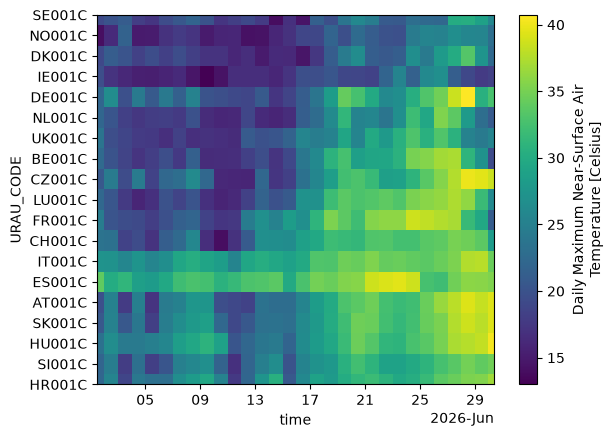

In [22]:
da.sel(time = "2026-06", URAU_CODE = cities).plot()